In [3]:
import time
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.signal import find_peaks

In [4]:
def wavelength_to_rgb(wavelength, gamma=0.8):
    R = G = B = 0.0
    if 380 <= wavelength <= 440:
        attenuation = 0.3 + 0.7 * (wavelength - 380) / (440 - 380)
        R = ((-(wavelength - 440) / (440 - 380)) * attenuation) ** gamma
        G = 0.0
        B = (1.0 * attenuation) ** gamma
    elif 440 <= wavelength <= 490:
        R = 0.0
        G = ((wavelength - 440) / (490 - 440)) ** gamma
        B = 1.0 ** gamma
    elif 490 <= wavelength <= 510:
        R = 0.0
        G = 1.0 ** gamma
        B = ((-(wavelength - 510) / (510 - 490))) ** gamma
    elif 510 <= wavelength <= 580:
        R = ((wavelength - 510) / (580 - 510)) ** gamma
        G = 1.0 ** gamma
        B = 0.0
    elif 580 <= wavelength <= 645:
        R = 1.0 ** gamma
        G = ((-(wavelength - 645) / (645 - 580))) ** gamma
        B = 0.0
    elif 645 <= wavelength <= 750:
        attenuation = 0.3 + 0.7 * (750 - wavelength) / (750 - 645)
        R = (1.0 * attenuation) ** gamma
        G = 0.0
        B = 0.0
    return (max(0.0, min(1.0, R)), max(0.0, min(1.0, G)), max(0.0, min(1.0, B)))

In [30]:
def plot_emission_spectrum_colab_style(
    df,
    nm_col='nm',
    intensity_col='Grey Val',
    prominence_percentage=0.12,
    x_min=400,
    x_max=750,
    fig_size=(15,2),
    min_brightness=0.1,
    min_needle_max_width_nm=0.2,
    max_needle_max_width_nm=0.8,
    needle_shape_power=4,
    glow_width_multiplier=1.5,
    glow_alpha=0.25,
    dpi=300,
    save_prefix='colab_emission',
    dark_mode=True,
    label_y=1.05,
    label_rotation=60,
    label_fontsize=8,
    title_y=1.10,
):
    df2 = df[(df[nm_col] >= x_min) & (df[nm_col] <= x_max)].copy().sort_values(by=nm_col).reset_index(drop=True)
    minv = df2[intensity_col].min()
    maxv = df2[intensity_col].max()
    rng = maxv - minv
    if rng == 0:
        df2['Normalized_Intensity'] = 1.0
    else:
        df2['Normalized_Intensity'] = (df2[intensity_col] - minv) / rng

    dynamic_prominence = prominence_percentage * (rng if rng>0 else 1.0)
    peaks, props = find_peaks(df2[intensity_col].values, prominence=dynamic_prominence)

    fig, ax = plt.subplots(figsize=fig_size)

    # spectrum box always black; page background depends on mode
    ax.set_facecolor('black')
    fig.patch.set_facecolor('black' if dark_mode else 'white')

    # axis text/tick colors read on black spectrum box; title contrasts page
    axis_text_color = 'white'      # tick labels / labels that sit on black box
    title_color = 'white' if dark_mode else 'black'
    stroke_col = 'black' if dark_mode else 'white'

    # expand axis region so rotated labels and ticks remain inside the black box
    # (adjust these numbers if you want more/less space)
    plt.subplots_adjust(top=0.82, bottom=0.12, left=0.03, right=0.97)
    ax.set_position([0.03, 0.12, 0.94, 0.70])  # [left, bottom, width, height]

    ax.yaxis.set_visible(False)
    ax.set_xlabel('Wavelength (nm)', color=axis_text_color)
    major_locator = ticker.MultipleLocator(50)
    minor_locator = ticker.MultipleLocator(10)
    ax.xaxis.set_major_locator(major_locator)
    ax.xaxis.set_minor_locator(minor_locator)
    # ensure ticks and tick labels are white and sit on the black axis
    ax.tick_params(axis='x', which='major', colors=axis_text_color, labelsize=10, pad=6)
    ax.tick_params(axis='x', which='minor', colors=axis_text_color, length=4, width=0.5)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(0, 1)

    y_coords = np.linspace(0,1,60)

    # enforce a sane font size so light/dark parity holds
    label_fontsize = int(label_fontsize)

    for p_idx in peaks:
        peak_nm = float(df2.iloc[p_idx][nm_col])
        peak_norm = float(df2.iloc[p_idx]['Normalized_Intensity'])

        base_rgb = wavelength_to_rgb(peak_nm)
        final_scale = min_brightness + (1 - min_brightness) * peak_norm
        colored_rgb = (base_rgb[0]*final_scale, base_rgb[1]*final_scale, base_rgb[2]*final_scale)

        scaled_max_width_nm = min_needle_max_width_nm + (max_needle_max_width_nm - min_needle_max_width_nm) * peak_norm
        width_profile = (4 * y_coords * (1 - y_coords)) ** needle_shape_power

        # glow
        glow_widths = scaled_max_width_nm * glow_width_multiplier * width_profile
        left = peak_nm - glow_widths/2
        right = peak_nm + glow_widths/2
        ax.fill_betweenx(y_coords, left, right, facecolor=colored_rgb, alpha=glow_alpha, linewidth=0)

        # core needle
        core_widths = scaled_max_width_nm * width_profile
        left2 = peak_nm - core_widths/2
        right2 = peak_nm + core_widths/2
        ax.fill_betweenx(y_coords, left2, right2, facecolor=colored_rgb, linewidth=0)

        # label (centered, rotated) with stroke for readability; clip_on=False keeps them visible
        label = f'{peak_nm:.2f}'
        txt = ax.text(peak_nm, label_y, label,
                      color=axis_text_color, ha='center', va='bottom',
                      fontsize=label_fontsize, rotation=label_rotation, rotation_mode='anchor',
                      clip_on=False)
        try:
            import matplotlib.patheffects as pe
            txt.set_path_effects([pe.Stroke(linewidth=2, foreground=stroke_col), pe.Normal()])
        except Exception:
            pass

    ax.set_title('Colab-style Emission Spectrum', color=title_color, y=title_y)

    ts = datetime.now().strftime('%Y%m%d-%H%M%S')
    mode_tag = 'dark' if dark_mode else 'light'
    out_png = f'{save_prefix}_{mode_tag}_{ts}.png'
    out_csv = f'{save_prefix}_peaks_{mode_tag}_{ts}.csv'

    peaks_df = df2.iloc[peaks].copy()
    peaks_df = peaks_df.rename(columns={nm_col:'wl', intensity_col:'intensity'})
    peaks_df['norm'] = peaks_df['Normalized_Intensity']
    peaks_df.to_csv(out_csv, index=False)

    plt.savefig(out_png, facecolor=fig.get_facecolor(), bbox_inches='tight', dpi=dpi)
    plt.show()

    return dict(png=out_png, csv=out_csv, peaks=peaks_df)

Using columns: nm Grey Val


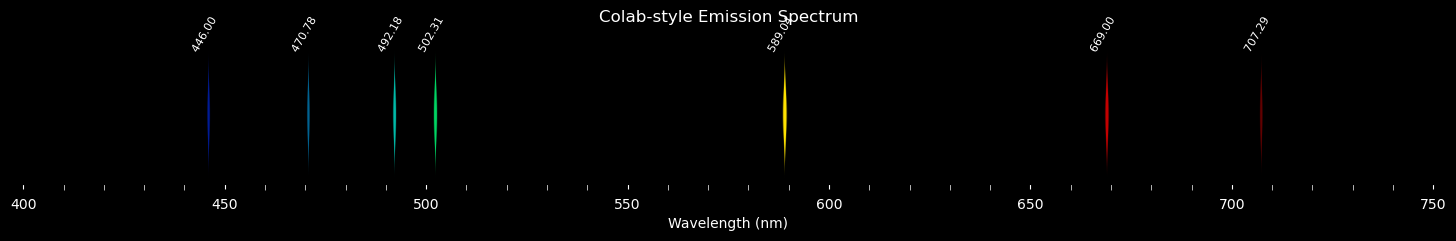

Saved dark: emulate_colab_dark_20260527-113258.png emulate_colab_peaks_dark_20260527-113258.csv


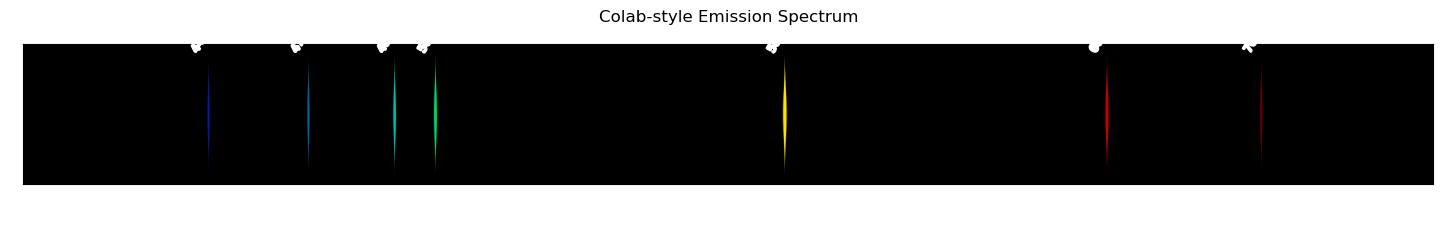

Saved light: emulate_colab_light_20260527-113259.png emulate_colab_peaks_light_20260527-113259.csv


In [31]:
# set this to your data file (Excel or CSV). The example assumes 'he test.xlsx' like your Colab.
fn = 'he test.xlsx'  # change if needed
# load (Excel/CSV auto-detect)
if fn.lower().endswith('.xlsx') or fn.lower().endswith('.xls'):
    df = pd.read_excel(fn, sheet_name=0)
else:
    df = pd.read_csv(fn)

# auto-detect columns (same logic as before)
cols = [c.lower() for c in df.columns]
nm_col = next((c for c in df.columns if 'nm' in c.lower() or 'wavelength' in c.lower() or 'lambda' in c.lower()), None)
val_col = next((c for c in df.columns if 'grey' in c.lower() or 'intensity' in c.lower() or 'value' in c.lower()), None)
print('Using columns:', nm_col, val_col)

# Dark mode image
res_dark = plot_emission_spectrum_colab_style(
    df,
    nm_col=nm_col,
    intensity_col=val_col,
    dark_mode=True,
    save_prefix='emulate_colab'
)
print('Saved dark:', res_dark['png'], res_dark['csv'])

# Light mode image
res_light = plot_emission_spectrum_colab_style(
    df,
    nm_col=nm_col,
    intensity_col=val_col,
    dark_mode=False,
    save_prefix='emulate_colab'
)
print('Saved light:', res_light['png'], res_light['csv'])

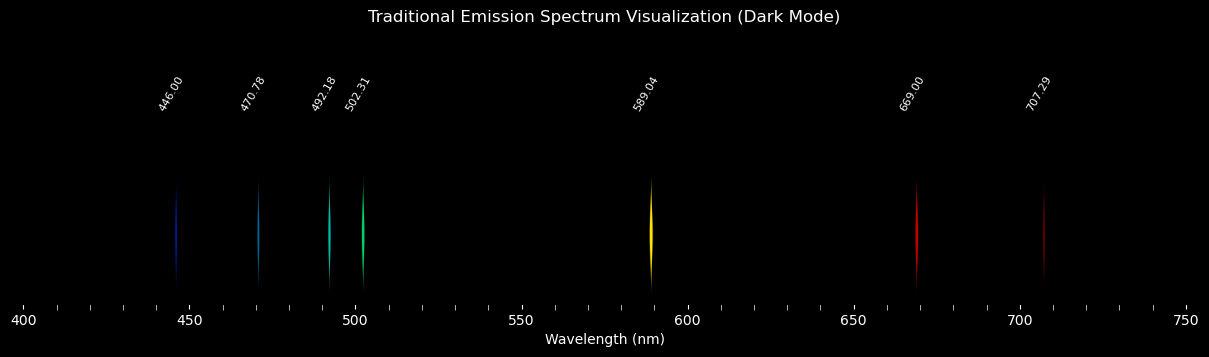

This dark mode visualization shows the emission spectrum as a horizontal bar with sharp, distinct vertical lines.
Each line's color is determined by its wavelength, and its brightness and thickness reflect the intensity at that point, and its height is uniformly set by the 'max_needle_y_scale' parameter, against a black background.
The overall figure and text are optimized for a dark theme.


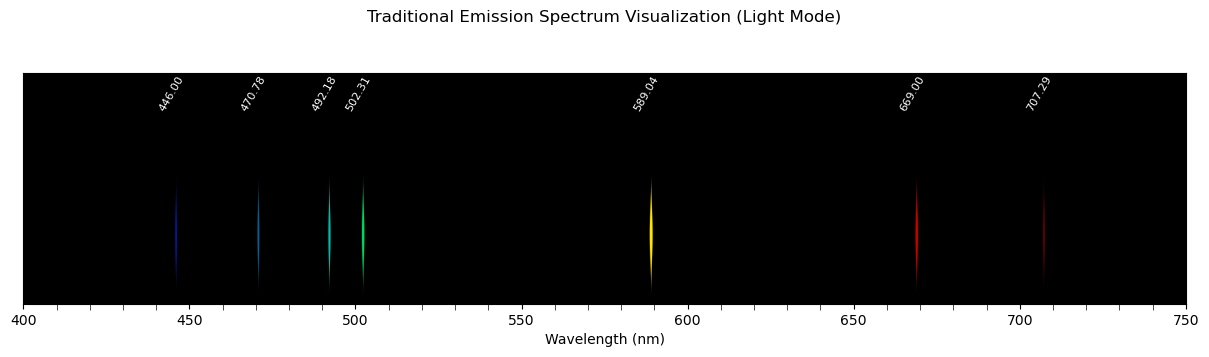

This light mode visualization shows the emission spectrum as a horizontal bar with sharp, distinct vertical lines.
Each line's color is determined by its wavelength, and its brightness and thickness reflect the intensity at that point, and its height is uniformly set by the 'max_needle_y_scale' parameter, against a black background.
The overall figure and text are optimized for a light theme.


In [40]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import find_peaks
import matplotlib.ticker as ticker # Import ticker

# --- Ensure df and df_filtered are available ---
# This section is added to ensure data is loaded and filtered if not already in session

# Check if 'df' DataFrame exists, if not, load it
if 'df' not in locals() or df is None:
    url = "https://docs.google.com/spreadsheets/d/1oz8Bpbbe8lhDfOaNUL-lwlsI6Ls6hjAu/export?format=csv"
    df = pd.read_csv(url)

# Filter the DataFrame for 'nm' values between 400 and 750
df_filtered = df[(df['nm'] >= 400) & (df['nm'] <= 750)].copy()

# Sort by 'nm' to ensure correct neighbor comparison and plotting order
df_filtered = df_filtered.sort_values(by='nm').reset_index(drop=True)

# Function to convert wavelength (nm) to RGB color
def wavelength_to_rgb(wavelength, gamma=0.8):
    """
    Converts a wavelength in nanometers to an RGB color tuple (0-1 range).
    Based on code by Dan Bruton (astro.sfasu.edu/sfop03/bruton.htm)
    """
    R, G, B = 0.0, 0.0, 0.0

    if wavelength >= 380 and wavelength <= 440:
        attenuation = 0.3 + 0.7 * (wavelength - 380) / (440 - 380)
        R = ((-(wavelength - 440) / (440 - 380)) * attenuation) ** gamma
        G = 0.0
        B = (1.0 * attenuation) ** gamma
    elif wavelength >= 440 and wavelength <= 490:
        R = 0.0
        G = ((wavelength - 440) / (490 - 440)) ** gamma
        B = (1.0) ** gamma
    elif wavelength >= 490 and wavelength <= 510:
        R = 0.0
        G = (1.0) ** gamma
        B = ((-(wavelength - 510) / (510 - 490))) ** gamma
    elif wavelength >= 510 and wavelength <= 580:
        R = ((wavelength - 510) / (580 - 510)) ** gamma
        G = (1.0) ** gamma
        B = 0.0
    elif wavelength >= 580 and wavelength <= 645:
        R = (1.0) ** gamma
        G = ((-(wavelength - 645) / (645 - 580))) ** gamma
        B = 0.0
    elif wavelength >= 645 and wavelength <= 750:
        attenuation = 0.3 + 0.7 * (750 - wavelength) / (750 - 645)
        R = (1.0 * attenuation) ** gamma
        G = 0.0
        B = 0.0
    # Wavelengths outside 380-750 nm will be black (0,0,0) by default initialization

    # Ensure values are within 0-1 range
    return (max(0.0, min(1.0, R)), max(0.0, min(1.0, G)), max(0.0, min(1.0, B)))

def plot_emission_spectrum(
    data_df,
    nm_col='nm',
    intensity_col='Grey Val',
    prominence_percentage=0.12,
    x_min=400,
    x_max=750,
    fig_size=(15, 2),
    min_brightness=0.1,
    save_path=None,
    min_needle_max_width_nm=0.2,
    max_needle_max_width_nm=0.8,
    needle_shape_power=4,
    glow_width_multiplier=1.5,
    glow_alpha=0.25,
    dpi=600,
    mode='dark',
    show_grid=True,
    peak_label_y_position=0.9, # New parameter with default
    max_needle_y_scale=0.8 # New parameter for controlling max needle height relative to spectrum bar
):

    # Filter the DataFrame for 'nm' values within the specified range
    df_plot_data = data_df[(data_df[nm_col] >= x_min) & (data_df[nm_col] <= x_max)].copy()
    df_plot_data = df_plot_data.sort_values(by=nm_col).reset_index(drop=True)

    # Normalize Intensity (Grey Val) for intensity scaling
    min_intensity_val = df_plot_data[intensity_col].min()
    max_intensity_val = df_plot_data[intensity_col].max()
    intensity_range = max_intensity_val - min_intensity_val

    if intensity_range == 0:
        df_plot_data['Normalized_Intensity'] = 1.0
    else:
        df_plot_data['Normalized_Intensity'] = (df_plot_data[intensity_col] - min_intensity_val) / intensity_range

    # --- Peak Detection ---
    dynamic_prominence = prominence_percentage * intensity_range
    peaks, _ = find_peaks(df_plot_data[intensity_col], prominence=dynamic_prominence)

    # Create the plot
    plt.figure(figsize=fig_size)
    ax = plt.gca() # Get current axes

    # Set figure background and text colors based on mode
    if mode == 'dark':
        figure_bg_color = 'black'
        text_color = 'white'
        grid_color = 'darkgrey'
    else: # light mode
        figure_bg_color = 'white'
        text_color = 'black'
        grid_color = 'lightgrey'

    plt.gcf().set_facecolor(figure_bg_color) # Set figure background color
    ax.set_facecolor('black') # Always keep the spectrum plot area (axes) background black

    # Remove Y-axis completely as intensity is shown by brightness/color
    ax.yaxis.set_visible(False)

    # Set X-axis labels and color
    plt.xlabel('Wavelength (nm)', color=text_color)

    # Set major and minor tick locators
    major_locator = ticker.MultipleLocator(50) # Major ticks every 50nm
    minor_locator = ticker.MultipleLocator(10) # Minor ticks every 10nm
    ax.xaxis.set_major_locator(major_locator)
    ax.xaxis.set_minor_locator(minor_locator)

    # Set tick parameters for both major and minor ticks
    ax.tick_params(axis='x', which='major', colors=text_color, labelsize=10)
    ax.tick_params(axis='x', which='minor', colors=text_color, length=4, width=0.5)

    # Set X-axis limits
    plt.xlim(x_min, x_max)

    # Set a fixed y-range for the vertical lines to appear as a bar
    plt.ylim(0, 1) # All lines will span this fixed y-range

    # Plot sharp distinct lines for each identified peak using fill_betweenx for needle shape
    for peak_index in peaks:
        peak_nm = df_plot_data.iloc[peak_index][nm_col]
        peak_normalized_intensity = df_plot_data.iloc[peak_index]['Normalized_Intensity']

        # Get base RGB color for the peak wavelength
        base_rgb = wavelength_to_rgb(peak_nm)

        # Scale the intensity factor for brightness
        final_intensity_scale = min_brightness + (1 - min_brightness) * peak_normalized_intensity

        colored_rgb = (base_rgb[0] * final_intensity_scale,
                       base_rgb[1] * final_intensity_scale,
                       base_rgb[2] * final_intensity_scale)

        # Scale the maximum width of the needle based on normalized intensity
        scaled_max_width_nm = min_needle_max_width_nm + (max_needle_max_width_nm - min_needle_max_width_nm) * peak_normalized_intensity

        # Calculate the actual height the needle should reach. Now fixed by max_needle_y_scale.
        current_peak_render_height = max_needle_y_scale

        # Define y-coordinates for the needle shape, spanning from 0 to current_peak_render_height
        y_coords_render = np.linspace(0, current_peak_render_height, 50)
        # Calculate normalized y-coordinates for the width profile, ensuring the bell shape is maintained
        # This normalization is relative to the peak's actual render height.
        y_coords_normalized_for_width = y_coords_render / current_peak_render_height if current_peak_render_height > 0 else np.zeros_like(y_coords_render)

        # Use a power-law profile for the width, making tips slimmer
        width_profile_factor = (4 * y_coords_normalized_for_width * (1 - y_coords_normalized_for_width))**needle_shape_power # Ranges from 0 to 1

        # --- Plot the GLOW effect first ---
        glow_current_widths_nm = scaled_max_width_nm * glow_width_multiplier * width_profile_factor
        glow_x_left = peak_nm - glow_current_widths_nm / 2
        glow_x_right = peak_nm + glow_current_widths_nm / 2
        ax.fill_betweenx(y_coords_render, glow_x_left, glow_x_right, facecolor=colored_rgb, alpha=glow_alpha)

        # --- Plot the main NEEDLE on top of the glow ---
        current_widths_nm = scaled_max_width_nm * width_profile_factor
        x_left = peak_nm - current_widths_nm / 2
        x_right = peak_nm + current_widths_nm / 2
        ax.fill_betweenx(y_coords_render, x_left, x_right, facecolor=colored_rgb)

        # Add text label for the peak wavelength with rotation, always white
        ax.text(peak_nm, peak_label_y_position, f'{peak_nm:.2f}',
                color='white', ha='center', va='bottom', fontsize=8,
                rotation=60, rotation_mode='anchor')

    plt.title(f'Traditional Emission Spectrum Visualization ({mode.capitalize()} Mode)', color=text_color, y=1.1, pad=20) # Raised title with y parameter
    if show_grid:
        plt.grid(True, color=grid_color, linestyle=':', linewidth=0.5) # Grid color based on mode

    # Save the plot if a save_path is provided
    if save_path:
        plt.savefig(save_path, facecolor=plt.gcf().get_facecolor(), bbox_inches='tight', dpi=dpi)
        print(f"Plot saved to {save_path}")
        print(f"[Download Image]({save_path})")

    plt.show()

    print(f"This {mode} mode visualization shows the emission spectrum as a horizontal bar with sharp, distinct vertical lines.")
    print("Each line's color is determined by its wavelength, and its brightness and thickness reflect the intensity at that point, and its height is uniformly set by the 'max_needle_y_scale' parameter, against a black background.")
    if mode == 'dark':
        print("The overall figure and text are optimized for a dark theme.")
    else:
        print("The overall figure and text are optimized for a light theme.")

# --- Generate two plots: one dark mode, one light mode ---
# with shorter peaks due to reduced max_needle_y_scale.

# Dark Mode Plot with shorter peaks
plot_emission_spectrum(
    df_filtered,
    min_needle_max_width_nm=0.2,
    max_needle_max_width_nm=0.8,
    needle_shape_power=4,
    glow_width_multiplier=1.5,
    glow_alpha=0.25,
    dpi=600,
    mode='dark',
    show_grid=False,
    fig_size=(15, 3), # Keep increased height for labels
    peak_label_y_position=0.9, # Labels inside the box
    max_needle_y_scale=0.6 # Increased to make peaks taller
)

# Light Mode Plot with shorter peaks
plot_emission_spectrum(
    df_filtered,
    min_needle_max_width_nm=0.2,
    max_needle_max_width_nm=0.8,
    needle_shape_power=4,
    glow_width_multiplier=1.5,
    glow_alpha=0.25,
    dpi=600,
    mode='light',
    show_grid=False,
    fig_size=(15, 3), # Keep increased height for labels
    peak_label_y_position=0.9, # Labels inside the box
    max_needle_y_scale=0.6 # Increased to make peaks taller
)